# Imports and Data Loading


---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files

# Load dataset
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

# Show first 5 rows
display(df.head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


> # Data Cleaning & Initial Analysis

In [ ]:
# Technical info
print("--- Data Info ---")
print(df.info())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())
#df = df.dropna()
#print("\n--- After Dropping NAN values ---")
#print(df.isna().sum())
#print(df.isnull().sum())

# Drop high cardinality and unique identifiers
cols_to_drop = ['FILENAME', 'URL', 'Domain', 'Title']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Drop duplicates
df = df.drop_duplicates()

# Statistical summary
print("\n--- Statistical Summary ---")
print(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 

> # Encoding & Visualizing Balance

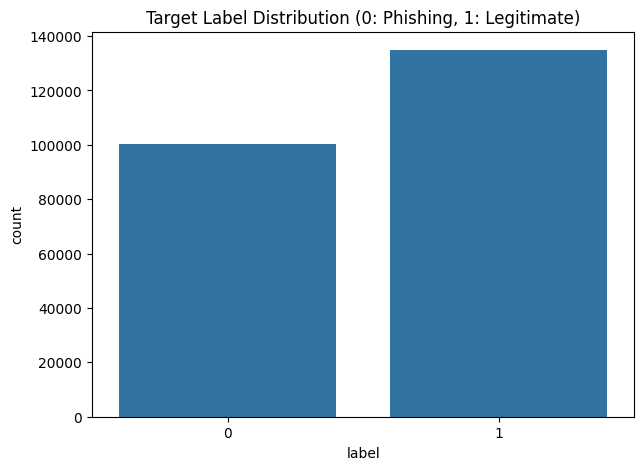

label
1    134850
0    100137
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Ensure label is int
if 'label' in df.columns:

    df['label'] = df['label'].replace([np.inf, -np.inf], np.nan)


    df.dropna(subset=['label'], inplace=True)


    df['label'] = df['label'].astype(int)

# Visualize class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df)
plt.title('Target Label Distribution (0: Phishing, 1: Legitimate)')
plt.show()

print(df['label'].value_counts())

> ## Correlation Matrix

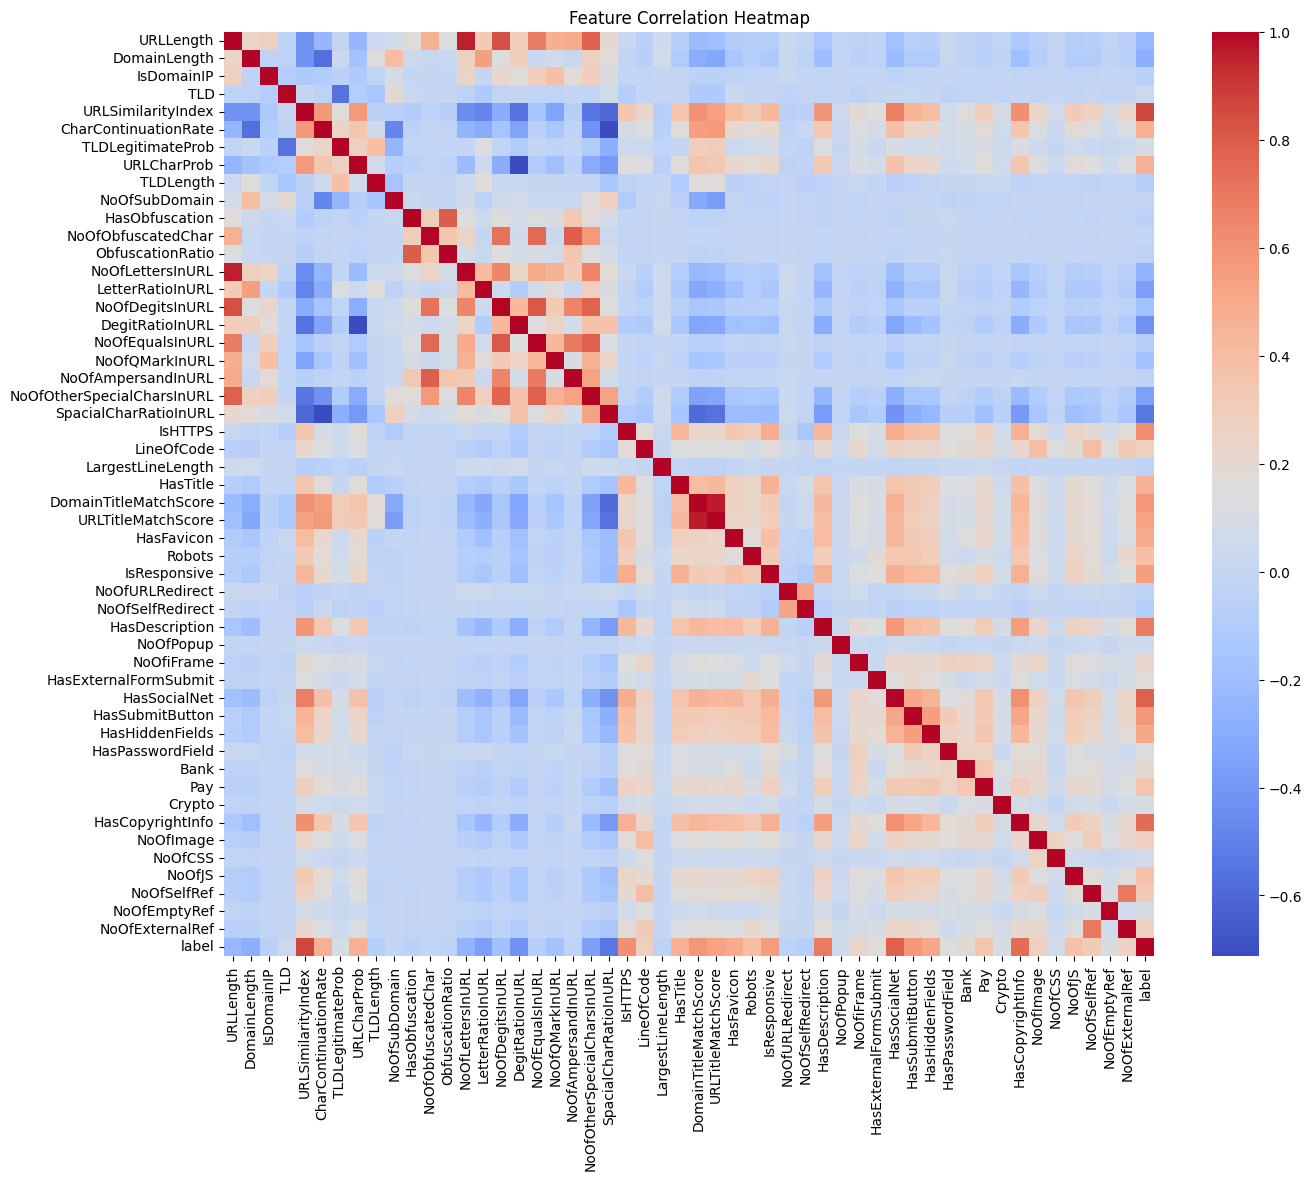

In [ ]:
plt.figure(figsize=(15, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### Selecting Top 15 Features (Dimension Reduction)

---



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import pickle

# Features + label
X = df.drop('label', axis=1)
y = df['label']

# Train/test split (IMPORTANT)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline (FINAL SYSTEM)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=7)),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Train
pipeline.fit(X_train, y_train)

# Save ONLY ONE object
pickle.dump(pipeline, open("pipeline.pkl", "wb"))

# Save feature order (VERY IMPORTANT for UI)
import pickle
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))

Top 15 Features Selected: ['URLSimilarityIndex', 'CharContinuationRate', 'URLCharProb', 'SpacialCharRatioInURL', 'IsHTTPS', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasCopyrightInfo']


> ## Train/Test Split & SMOTE



In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_final.drop('label', axis=1)
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Balance the data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Final training set size: {X_train_res.shape}")

Final training set size: (215760, 15)


# PCA & Scaling (Advanced Dimension Reduction)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Reduce to 7 components for a more "pattern-focused" model
pca = PCA(n_components=7)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Reduced to {pca.n_components_} PCA components.")

Reduced to 7 PCA components.


# Model Training

---



In [ ]:
#importing models

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


# for evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


> ## Defining Models

In [ ]:

# Defining the models that will be evaluated

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        class_weight='balanced'
    ),
    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
    ),
    "SVM": SVC(kernel='linear')
}

> ## Training

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
# model training

results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train_res)
    # Predictions
    y_pred = model.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })
    print(f"\n{name}")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    # print("\nClassification Report:")
    # print(classification_report(y_test, y_pred))




Logistic Regression
Accuracy Score: 0.9896

Decision Tree
Accuracy Score: 0.9933

KNN
Accuracy Score: 0.9963

Random Forest
Accuracy Score: 0.9932

XGBoost
Accuracy Score: 0.9933

SVM
Accuracy Score: 0.9896


> # Evaluation

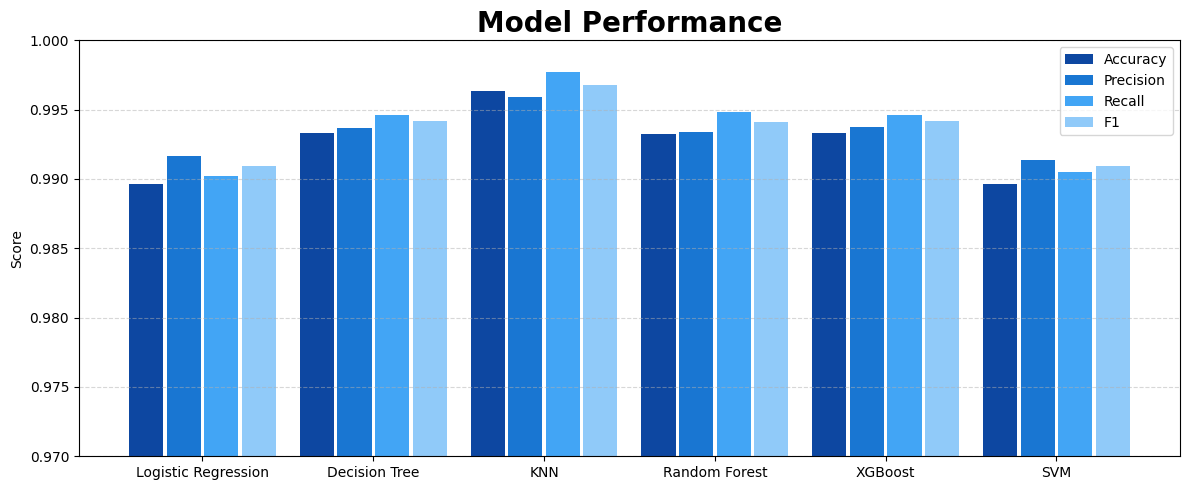

In [ ]:
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame(results)
metrics_df.set_index("Model", inplace=True)

# Create plot
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#0d47a1", "#1976d2", "#42a5f5", "#90caf9"]

# Number of models
x = np.arange(len(metrics_df.index))
width = 0.2

# Plot bars
ax.bar(x - 1.65*width, metrics_df["Accuracy"], width, label="Accuracy", color=colors[0])
ax.bar(x - 0.55*width, metrics_df["Precision"], width, label="Precision", color=colors[1])
ax.bar(x + 0.55*width, metrics_df["Recall"], width, label="Recall", color=colors[2])
ax.bar(x + 1.65*width, metrics_df["F1"], width, label="F1", color=colors[3])

# Labels and styling
ax.set_title("Model Performance", fontsize=20, fontweight='bold')
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index)

# Grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
ax.legend()
ax.set_ylim(0.97, 1.0)

plt.tight_layout()
plt.show()


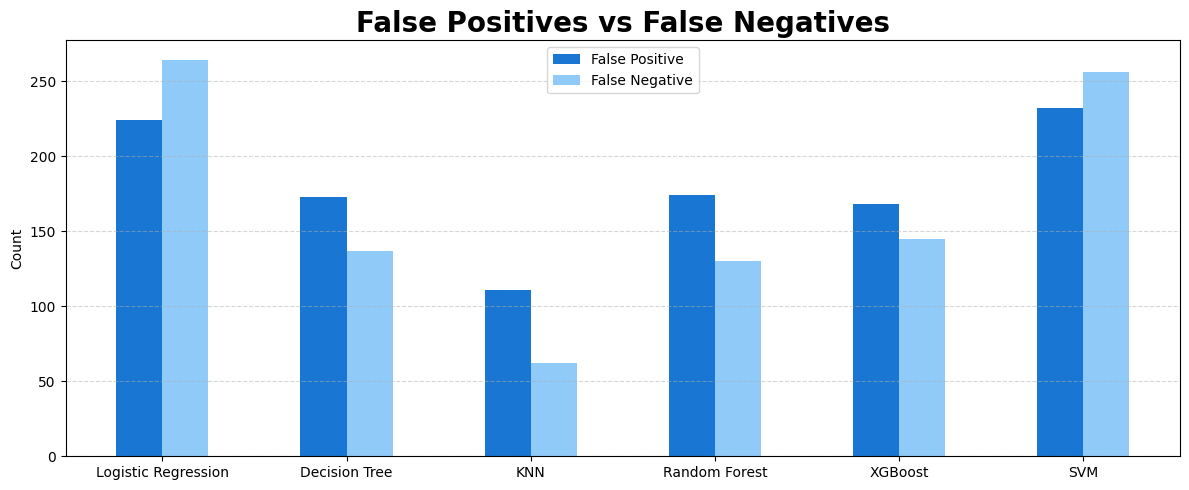

In [ ]:
fp_fn_results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train_res)
    y_pred = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)
    FP = cm[0][1]
    FN = cm[1][0]

    fp_fn_results.append({
        "Model": name,
        "False Positive": FP,
        "False Negative": FN
    })

fp_fn_df = pd.DataFrame(fp_fn_results)
fp_fn_df.set_index("Model", inplace=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(fp_fn_df.index))
width = 0.25
colors = ["#1976d2", "#90caf9"]

ax.bar(x - width/2, fp_fn_df["False Positive"], width, label="False Positive", color=colors[0])
ax.bar(x + width/2, fp_fn_df["False Negative"], width, label="False Negative", color=colors[1])

# Styling
ax.set_title("False Positives vs False Negatives", fontsize=20, fontweight='bold')
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(fp_fn_df.index)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
# rf_model.fit(X_train_pca, y_train_res)

# y_pred = rf_model.predict(X_test_pca)

# print("\n===== Evaluation Results =====")
# print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# # Plot Confusion Matrix
# plt.figure(figsize=(6, 4))
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
# plt.title('Final Confusion Matrix')
# plt.show()